# Preprocessing Transactions

This file preprocesses the transaction data 

In [3]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sys, os, glob
import re
import zipfile
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, LongType, IntegerType, DateType, DoubleType
from datetime import datetime, timedelta

In [4]:
sys.path.insert(0, "../scripts")
from spark_setup import get_spark
spark = get_spark()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/16 16:51:21 WARN Utils: Your hostname, Poppys-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.100.130 instead (on interface en0)
26/09/16 16:51:21 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/Users/poppyvangerrevink/Documents/GitHub/industry-project-group-21/.venv/lib/python3.13/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/16 16:51:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where app

In [5]:
# Unzip the data files
zip_file_path = [
    "../data/project-2-bnpl-tables-part1.zip",
    "../data/project-2-bnpl-tables-part2.zip",
    "../data/project-2-bnpl-tables-part3.zip",
    "../data/project-2-bnpl-tables-part4.zip"
]

for zip_path in zip_file_path:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("../data/")
    

In [6]:
transactions1 = spark.read.parquet(".././data/tables/transactions_20210228_20210827_snapshot")
transactions2 = spark.read.parquet(".././data/tables/transactions_20210828_20220227_snapshot")
transactions3 = spark.read.parquet(".././data/tables/transactions_20220228_20220828_snapshot")

transactions1.write.mode('overwrite').parquet('.././data/landing/transactions/transactions1')
transactions2.write.mode('overwrite').parquet('.././data/landing/transactions/transactions2')
transactions3.write.mode('overwrite').parquet('.././data/landing/transactions/transactions3')

In [7]:
transactions = transactions1.union(transactions2).union(transactions3)

transactions.show()
transactions.count()

+-------+------------+------------------+--------------------+--------------+
|user_id|merchant_abn|      dollar_value|            order_id|order_datetime|
+-------+------------+------------------+--------------------+--------------+
|  18478| 62191208634|63.255848959735246|949a63c8-29f7-4ab...|    2021-08-20|
|      2| 15549624934| 130.3505283105634|6a84c3cf-612a-457...|    2021-08-20|
|  18479| 64403598239|120.15860593212783|b10dcc33-e53f-425...|    2021-08-20|
|      3| 60956456424| 136.6785200286976|0f09c5a5-784e-447...|    2021-08-20|
|  18479| 94493496784| 72.96316578355305|f6c78c1a-4600-4c5...|    2021-08-20|
|      3| 76819856970|  448.529684285612|5ace6a24-cdf0-4aa...|    2021-08-20|
|  18479| 67609108741|  86.4040605836911|d0e180f0-cb06-42a...|    2021-08-20|
|      3| 34096466752| 301.5793450525113|6fb1ff48-24bb-4f9...|    2021-08-20|
|  18482| 70501974849| 68.75486276223054|8505fb33-b69a-412...|    2021-08-20|
|      4| 49891706470| 48.89796461900801|ed11e477-b09f-4ae...|  

14195505

In [8]:
transactions.write.mode('overwrite').parquet('.././data/raw/transactions/full_transactions')
transactions = spark.read.parquet(".././data/raw/transactions/full_transactions")
transactions.show(truncate = False)

+-------+------------+------------------+------------------------------------+--------------+
|user_id|merchant_abn|dollar_value      |order_id                            |order_datetime|
+-------+------------+------------------+------------------------------------+--------------+
|11139  |96152467973 |16.213590228273233|785b0080-9e4b-471a-9b1f-6a8a9dc535c2|2022-08-20    |
|1      |98973094975 |86.97955945703498 |2560f7b0-ee5d-4b3e-bfc2-a00c011ff63c|2022-08-20    |
|11139  |56762458844 |31.513502323509194|0311717b-8b5b-410b-89f3-f6e984b54a30|2022-08-20    |
|1      |89502033586 |124.18468694868491|f8891626-f098-45bf-bd6b-a50d12823338|2022-08-20    |
|11139  |96161808980 |61.620445567668966|d90a421f-f1da-4bff-97ac-47b53fd841fd|2022-08-20    |
|2      |72472909171 |32.26524985312485 |523e0403-b677-4505-a8b8-fb9bce781127|2022-08-20    |
|11139  |91923722701 |11.331586767322225|f45a842b-0366-41d7-87e3-b7dd0fa13bec|2022-08-20    |
|3      |46380096952 |119.80011239189334|58d0f423-037c-43f0-

# Schema

In [9]:
transactions.printSchema()

root
 |-- user_id: long (nullable = true)
 |-- merchant_abn: long (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- order_datetime: date (nullable = true)



Ensure all datatypes are consistent across tables.

In [10]:
transactions = transactions.withColumn('user_id', F.col('user_id').cast(StringType()))
transactions = transactions.withColumn('merchant_abn', F.col('merchant_abn').cast(StringType()))
transactions.printSchema()

root
 |-- user_id: string (nullable = true)
 |-- merchant_abn: string (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- order_datetime: date (nullable = true)



# Missing Value Detection

In [11]:
transactions.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in transactions.columns
]).show()

+-------+------------+------------+--------+--------------+
|user_id|merchant_abn|dollar_value|order_id|order_datetime|
+-------+------------+------------+--------+--------------+
|      0|           0|           0|       0|             0|
+-------+------------+------------+--------+--------------+



# Business Filtering Rule

`dollar value` for any transaction needs be greater than 0.

In [12]:
def report_shape(df, label):
    n = df.count()
    print(f"{label}: {n:,} rows")
    return n

n0 = report_shape(transactions, "0. raw transactions")

# --- Business-rule filtering ---
# dollar_value must be strictly positive -- a $0 or negative transaction
# isn't a real purchase (refunds/corrections, if any, aren't modelled here).
step1 = transactions.filter(F.col("dollar_value") > 0)
n1 = report_shape(step1, "1. dollar_value > 0")

clean = step1
print(f"Retained: {n1:,} / {n0:,} ({n1/n0:.1%})")

0. raw transactions: 14,195,505 rows
1. dollar_value > 0: 14,195,505 rows
Retained: 14,195,505 / 14,195,505 (100.0%)


# Outlier Removal

Outlier removal on `dollar_value` (log-N IQR rule). Raw dollar_value is right-skewed (many small purchases, a long tail of large ones), so IQR is computed on log1p(dollar_value) rather than the raw scale. Per the log-N rule: flag values more than k x IQR from the box, where k = sqrt(log n) - 0.5 for n > 100.

/Users/poppyvangerrevink/Documents/GitHub/industry-project-group-21/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


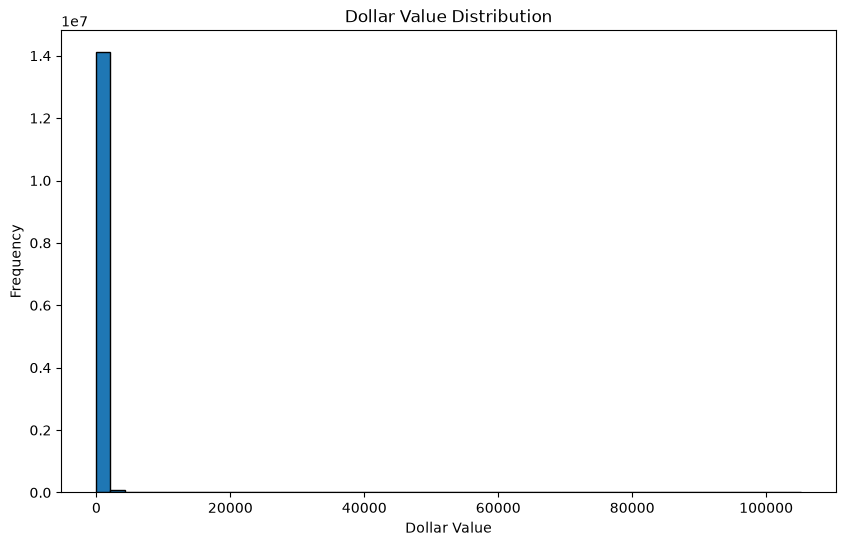

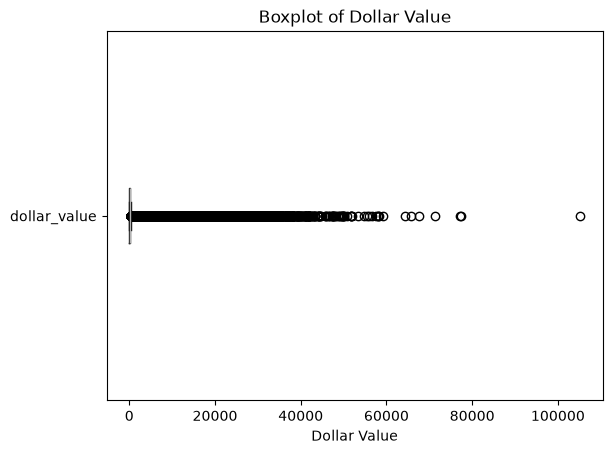

In [13]:
dollar = transactions.select("dollar_value").toPandas()

plt.figure(figsize=(10, 6))
plt.hist(dollar["dollar_value"], bins=50, edgecolor="black")
plt.xlabel("Dollar Value")
plt.ylabel("Frequency")
plt.title("Dollar Value Distribution")
plt.show()

dollar.boxplot(column="dollar_value", vert=False, grid=False)
plt.xlabel("Dollar Value")
plt.title("Boxplot of Dollar Value")
plt.show()

In [14]:
clean = clean.withColumn("log_dollar_value", F.log1p(F.col("dollar_value")))

n_rows = clean.count()
k = np.sqrt(np.log(n_rows)) - 0.5

q1, q3 = clean.approxQuantile("log_dollar_value", [0.25, 0.75], 0.0)
iqr = q3 - q1

lower_bound = q1 - k * iqr
upper_bound = q3 + k * iqr

print(f"n = {n_rows:,}, k = {k:.4f}")
print(f"Log-scale Q1: {q1:.4f}, Q3: {q3:.4f}, IQR: {iqr:.4f}")
print(f"Log-scale bounds: [{lower_bound:.4f}, {upper_bound:.4f}]")

n_before_outlier = report_shape(clean, "2. before outlier removal")

curated = clean.filter(
    (F.col("log_dollar_value") >= lower_bound) &
    (F.col("log_dollar_value") <= upper_bound)
).drop("log_dollar_value")

n_after_outlier = report_shape(curated, "3. after log-N IQR outlier removal")
print(f"Removed as outliers: {n_before_outlier - n_after_outlier:,}")

print(f"\nTotal retained: {n_after_outlier:,} / {n0:,} ({n_after_outlier/n0:.1%})")

n = 14,195,505, k = 3.5581
Log-scale Q1: 3.3006, Q3: 5.0203, IQR: 1.7196
Log-scale bounds: [-2.8181, 11.1390]
2. before outlier removal: 14,195,505 rows
3. after log-N IQR outlier removal: 14,195,501 rows
Removed as outliers: 4

Total retained: 14,195,501 / 14,195,505 (100.0%)


Store curated transaction dataset

In [15]:
transactions.write.mode("overwrite").parquet("../data/curated/transactions/")

# Join with Consumers data

Join on `user_id` and `order_datetime`.

In [16]:
consumer = spark.read.parquet("../data/curated/df_customers/")
consumer.show(truncate = False)

+-----------+-------+--------------+------------------+---------------------+-----------------+------------------------------+-----+--------+------+
|consumer_id|user_id|order_datetime|fraud_probability |is_same_day_duplicate|name             |address                       |state|postcode|gender|
+-----------+-------+--------------+------------------+---------------------+-----------------+------------------------------+-----+--------+------+
|712975     |5      |2021-10-04    |10.868364868449886|false                |Rebecca Blanchard|9271 Michael Manors Suite 651 |WA   |6355    |Female|
|712975     |5      |2022-01-11    |27.496186536467164|false                |Rebecca Blanchard|9271 Michael Manors Suite 651 |WA   |6355    |Female|
|712975     |5      |2022-02-08    |9.02022421158597  |false                |Rebecca Blanchard|9271 Michael Manors Suite 651 |WA   |6355    |Female|
|1331093    |17     |2022-02-14    |9.518525205093667 |false                |Alyssa Wilson    |44353 Natha

In [17]:
consumer.printSchema()
consumer.count() 

root
 |-- consumer_id: long (nullable = true)
 |-- user_id: long (nullable = true)
 |-- order_datetime: date (nullable = true)
 |-- fraud_probability: double (nullable = true)
 |-- is_same_day_duplicate: boolean (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- postcode: integer (nullable = true)
 |-- gender: string (nullable = true)



34864

In [18]:
transaction_cols = set(transactions.columns)
consumer_cols = set(consumer.columns)

overlapping_cols = transaction_cols & consumer_cols
print(overlapping_cols)

{'user_id', 'order_datetime'}


In [19]:
transactions.count()

14195505

In [20]:
c_transactions = (
    transactions
    .join(
        consumer,
        on=["user_id","order_datetime"],
        how="inner"
    )
)

c_transactions.show()

+-------+--------------+------------+-------------------+--------------------+-----------+------------------+---------------------+--------------+--------------------+-----+--------+------+
|user_id|order_datetime|merchant_abn|       dollar_value|            order_id|consumer_id| fraud_probability|is_same_day_duplicate|          name|             address|state|postcode|gender|
+-------+--------------+------------+-------------------+--------------------+-----------+------------------+---------------------+--------------+--------------------+-----+--------+------+
|     58|    2021-11-26| 43725628716|  2684.361417897887|52133cb6-4950-44c...|     838663| 9.241197906604826|                false|Adam Velazquez|  1075 Schultz Track|  NSW|    2403|  Male|
|     58|    2021-11-26| 45629217853|0.19607762574988435|e5b1880d-fb88-4fd...|     838663| 9.241197906604826|                false|Adam Velazquez|  1075 Schultz Track|  NSW|    2403|  Male|
|     58|    2021-11-26| 73499119023|  9.260984119

In [21]:
c_transactions.printSchema()
c_transactions.count()

root
 |-- user_id: string (nullable = true)
 |-- order_datetime: date (nullable = true)
 |-- merchant_abn: string (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- consumer_id: long (nullable = true)
 |-- fraud_probability: double (nullable = true)
 |-- is_same_day_duplicate: boolean (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- postcode: integer (nullable = true)
 |-- gender: string (nullable = true)



80560

# Join with Merchant data

Join on `merchant_abn`.

In [22]:
merchant = spark.read.parquet("../data/curated/merchant/")
merchant.show(truncate = False)

+------------+------------------------------+------------------------------------------------------------------------------------------------------------------+--------------------------------------------------------------------------------------+------------+---------+------------------+--------------+------------------+-----------------------+
|merchant_abn|name                          |tags                                                                                                              |category                                                                              |revenue_band|take_rate|total_revenue     |n_transactions|avg_order_value   |avg_merchant_fraud_prob|
+------------+------------------------------+------------------------------------------------------------------------------------------------------------------+--------------------------------------------------------------------------------------+------------+---------+------------------+--------------+

In [23]:
merchant.printSchema()
merchant.count() 

root
 |-- merchant_abn: long (nullable = true)
 |-- name: string (nullable = true)
 |-- tags: string (nullable = true)
 |-- category: string (nullable = true)
 |-- revenue_band: string (nullable = true)
 |-- take_rate: double (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- n_transactions: long (nullable = true)
 |-- avg_order_value: double (nullable = true)
 |-- avg_merchant_fraud_prob: double (nullable = true)



4026

In [24]:
transaction_cols = set(c_transactions.columns)
merchant_cols = set(merchant.columns)

overlapping_cols = transaction_cols & merchant_cols
print(overlapping_cols)

{'merchant_abn', 'name'}


In [25]:
c_transactions.select("merchant_abn", "name").show(10, False)
merchant.select("merchant_abn", "name").show(10, False)


+------------+--------------+
|merchant_abn|name          |
+------------+--------------+
|43725628716 |Adam Velazquez|
|45629217853 |Adam Velazquez|
|73499119023 |Adam Velazquez|
|30623214058 |Terry Martin  |
|79417999332 |Terry Martin  |
|18305506006 |Terry Martin  |
|96244711717 |Terry Martin  |
|34967436738 |Terry Martin  |
|16248082282 |Terry Martin  |
|45629217853 |Aaron Hall    |
+------------+--------------+
only showing top 10 rows
+------------+------------------------------+
|merchant_abn|name                          |
+------------+------------------------------+
|76819856970 |Egestas Blandit Ltd           |
|34096466752 |Nullam Enim Ltd               |
|46804135891 |Suspendisse Dui Corporation   |
|32361057556 |Orci In Consequat Corporation |
|30458474292 |Euismod Est Foundation        |
|23661821077 |Suspendisse Eleifend Corp.    |
|45380641195 |Nisl Arcu Iaculis Incorporated|
|49505931725 |Suspendisse Ac Associates     |
|39869100896 |Vivamus Nisi Mauris Corp.     |
|76

In [26]:
# so as to not confuse customer name with merchant name
merchant = merchant.withColumnRenamed("name", "merchant_name")
merchant.write.mode("overwrite").parquet("../data/curated/df_merchants/")
spark.read.parquet("../data/curated/df_merchants/").printSchema()

root
 |-- merchant_abn: long (nullable = true)
 |-- merchant_name: string (nullable = true)
 |-- tags: string (nullable = true)
 |-- category: string (nullable = true)
 |-- revenue_band: string (nullable = true)
 |-- take_rate: double (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- n_transactions: long (nullable = true)
 |-- avg_order_value: double (nullable = true)
 |-- avg_merchant_fraud_prob: double (nullable = true)



In [27]:
df_transactions = (
    c_transactions
    .join(
        merchant,
        on=["merchant_abn"],
        how="inner"
    )
)

df_transactions.show()

+------------+-------+--------------+-------------------+--------------------+-----------+------------------+---------------------+----------------+--------------------+-----+--------+------+--------------------+--------------------+--------------------+------------+---------+------------------+--------------+------------------+-----------------------+
|merchant_abn|user_id|order_datetime|       dollar_value|            order_id|consumer_id| fraud_probability|is_same_day_duplicate|            name|             address|state|postcode|gender|       merchant_name|                tags|            category|revenue_band|take_rate|     total_revenue|n_transactions|   avg_order_value|avg_merchant_fraud_prob|
+------------+-------+--------------+-------------------+--------------------+-----------+------------------+---------------------+----------------+--------------------+-----+--------+------+--------------------+--------------------+--------------------+------------+---------+-------------

In [28]:
# final row count
df_transactions.count()

71816

# Check for Duplicates
Check for duplicate rows based on `order_id`

In [29]:
df_transactions.count() - df_transactions.select("order_id").distinct().count()

179

In [30]:
different_fraud_probability = (
    df_transactions
    .groupBy("order_id", "order_datetime")
    .agg(
        F.count("*").alias("row_count"),
        F.countDistinct("fraud_probability").alias("unique_fraud_probabilities")
    )
    .filter(
        (F.col("row_count") > 1) &
        (F.col("unique_fraud_probabilities") > 1)
    )
)

different_fraud_probability.show()
different_fraud_probability.count()

+--------+--------------+---------+--------------------------+
|order_id|order_datetime|row_count|unique_fraud_probabilities|
+--------+--------------+---------+--------------------------+
+--------+--------------+---------+--------------------------+



0

In [31]:
duplicates = (
    df_transactions
    .groupBy("order_id", "order_datetime")
    .count()
    .filter(F.col("count") > 1)
)

duplicate_rows = (
    df_transactions
    .join(
        duplicates.select("order_id", "order_datetime"),
        on=["order_id", "order_datetime"],
        how="inner"
    )
)

duplicate_rows.filter(
    ~F.col("is_same_day_duplicate")
).count()


0

Since all duplicates have `is_same_day_duplicate == True` and `fraud_probability` is the same for duplicate rows, we won't remove duplicates

# Save Final Curated Full Transactions Dataset

In [32]:
df_transactions.printSchema()
df_transactions.write.mode("overwrite").parquet("../data/curated/df_transactions/")
spark.read.parquet("../data/curated/df_transactions/")

root
 |-- merchant_abn: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- order_datetime: date (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- consumer_id: long (nullable = true)
 |-- fraud_probability: double (nullable = true)
 |-- is_same_day_duplicate: boolean (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- postcode: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- merchant_name: string (nullable = true)
 |-- tags: string (nullable = true)
 |-- category: string (nullable = true)
 |-- revenue_band: string (nullable = true)
 |-- take_rate: double (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- n_transactions: long (nullable = true)
 |-- avg_order_value: double (nullable = true)
 |-- avg_merchant_fraud_prob: double (nullable = true)



merchant_abn,user_id,order_datetime,dollar_value,order_id,consumer_id,fraud_probability,is_same_day_duplicate,name,address,state,postcode,gender,merchant_name,tags,category,revenue_band,take_rate,total_revenue,n_transactions,avg_order_value,avg_merchant_fraud_prob
20985347699,14960,2021-12-04,2.5457227533362765,4ca8b959-cfc4-4bc...,660352,14.914512384497968,false,Andrew Medina,67415 Tran Ridges...,NSW,2106,Male,Semper Tellus PC,[(tent and awning...,tent and awning S...,a,6.1,859606.8993835656,62513,13.750850213292685,NULL
63290521567,15050,2021-12-04,8.827248024945517,d63bfab7-584b-475...,205600,40.053016492409085,false,Mark Henson,57619 Jessica Spr...,TAS,7025,Male,Vehicula Pellente...,((artist supply a...,artist supply and...,a,6.48,4402170.60110059,181876,24.204241357301623,NULL
49063322245,15050,2021-12-04,13203.431047301248,bc66c2a8-bf53-4cd...,205600,40.053016492409085,false,Mark Henson,57619 Jessica Spr...,TAS,7025,Male,Fringilla Donec A...,([antique shops -...,antique shops - s...,b,4.14,439823.2920577239,35,12566.379773077826,NULL
61085944703,15238,2021-12-04,2719.5258970107984,4be10996-2774-44b...,722980,10.541007313082803,false,Kevin Castillo,855 Newton Park S...,NSW,2264,Male,Vestibulum Mauris...,"((telecom), (a), ...",telecom,a,6.45,991123.518048757,397,2496.5327910548035,NULL
24852446429,526,2021-12-04,61.95414690030717,6a57e5ca-137d-4fe...,605326,11.96577377075349,false,Alyssa Price,3140 Michael Point,VIC,3823,Female,Erat Vitae LLP,[(florists suppli...,florists supplies...,c,2.94,8698779.502213048,289513,30.046248362640185,NULL
76021079177,526,2021-12-04,2373.244386103795,5c1106b6-4b36-480...,605326,11.96577377075349,false,Alyssa Price,3140 Michael Point,VIC,3823,Female,Pede Malesuada Ve...,"[(hobby, toy and ...","hobby, toy and ga...",b,3.47,167525.40439626208,115,1456.7426469240181,NULL
13514558491,526,2021-12-04,640.5680319156601,f1993d48-a521-4ee...,605326,11.96577377075349,false,Alyssa Price,3140 Michael Point,VIC,3823,Female,Magna Praesent PC,[(motor vehicle s...,motor vehicle sup...,a,6.78,5630544.501329678,17900,314.5555587335016,NULL
90984790127,526,2021-12-04,71.4601716488895,ace6f8c4-bd76-43d...,605326,11.96577377075349,false,Alyssa Price,3140 Michael Point,VIC,3823,Female,Lorem PC,[(digital goods: ...,digital goods: bo...,a,6.44,348265.3298615952,3277,106.27565757143581,NULL
21439773999,526,2021-12-04,36.53242501630421,515d3067-882a-497...,605326,11.96577377075349,false,Alyssa Price,3140 Michael Point,VIC,3823,Female,Mauris Non Institute,"([cable, satellit...","cable, satellite,...",a,6.1,9426656.544148413,120624,78.14909590254355,28.504479048104585
38700038932,554,2021-12-04,1732.2550051994526,e040b6c5-4e5d-47a...,1465289,8.291869719215637,false,Thomas Mullins,169 Rocha Lane,VIC,3521,Male,Etiam Bibendum In...,[(tent and awning...,tent and awning s...,a,6.31,9546185.360697312,7132,1338.5004712138689,NULL
